In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import json
import pandas as pd

data_dir = Path("/kaggle/working/surgwound")
data_dir.mkdir(parents=True, exist_ok=True)

file_path = data_dir / "val_question.json"
url = (
    "https://huggingface.co/datasets/"
    "xuxuxuxuxu/SurgWound/resolve/main/val_question.json"
)

# Reuse the downloaded file when rerunning this cell.
if not file_path.exists():
    urlretrieve(url, file_path)

with file_path.open("r", encoding="utf-8") as file:
    records = json.load(file)

print("JSON structure:", type(records).__name__)

if not isinstance(records, list):
    raise ValueError("Unexpected JSON structure. Inspect its keys before continuing.")

df = pd.DataFrame(records)

print("Question records:", len(df))
print("Columns:", df.columns.tolist())
print("Unique image names:", df["image_name"].nunique())

# Exclude the long encoded image strings from the display.
display(df[["image_name", "field", "answer"]].head(10))

JSON structure: list
Question records: 500
Columns: ['id', 'image_name', 'field', 'task_type', 'image', 'question', 'options', 'answer']
Unique image names: 69


,image_name,field,answer
0,1.jpg,Wound Location,Ankle
1,1.jpg,Healing Status,Healed
2,1.jpg,Closure Method,Invisible
3,1.jpg,Exudate Type,Non-existent
4,1.jpg,Erythema,Non-existent
5,1.jpg,Edema,Existent
6,1.jpg,Urgency Level,Home Care (Green): Manage with routine care
7,1.jpg,Infection Risk Assessment,Low
8,1005.jpg,Healing Status,Healed
9,1005.jpg,Exudate Type,Non-existent


In [3]:
risk_rows = df.loc[
    df["field"].eq("Infection Risk Assessment"),
    ["image_name", "answer"]
].copy()

print("Risk-labelled records:", len(risk_rows))
print("Unique risk-labelled images:", risk_rows["image_name"].nunique())

print("\nLabel counts:")
print(risk_rows["answer"].value_counts(dropna=False))

print("\nRepeated image names within risk records:")
print(risk_rows["image_name"].duplicated().sum())

Risk-labelled records: 69
Unique risk-labelled images: 69

Label counts:
answer
Low       54
Medium    14
High       1
Name: count, dtype: int64

Repeated image names within risk records:
0


<h3> Inspect Training File

In [4]:
from pathlib import Path
from urllib.request import urlretrieve
import json
import pandas as pd

data_dir = Path("/kaggle/working/surgwound")
data_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / "train_question.json"

train_url = (
    "https://huggingface.co/datasets/"
    "xuxuxuxuxu/SurgWound/resolve/main/train_question.json"
)

if not train_path.exists():
    print("Downloading the training file...")

    # Download to a temporary file so an interrupted download
    # is not mistaken for a complete file on the next run.
    temporary_path = data_dir / "train_question.json.part"
    urlretrieve(train_url, temporary_path)
    temporary_path.replace(train_path)

    print("Download complete.")
else:
    print("Using the existing training file.")

with train_path.open("r", encoding="utf-8") as file:
    train_records = json.load(file)

print("JSON structure:", type(train_records).__name__)

if not isinstance(train_records, list):
    raise ValueError("Unexpected JSON structure. Inspect it before continuing.")

train_df = pd.DataFrame(train_records)

print("Training question records:", len(train_df))
print("Columns:", train_df.columns.tolist())
print("Unique training image names:", train_df["image_name"].nunique())

# Display readable metadata, excluding encoded image strings.
display(train_df[["image_name", "field", "answer"]].head(10))

Download complete.
JSON structure: list
Training question records: 3435
Columns: ['id', 'image_name', 'field', 'task_type', 'image', 'question', 'options', 'answer']
Unique training image names: 480


,image_name,field,answer
0,606.jpg,Wound Location,Abdomen
1,606.jpg,Healing Status,Healed
2,606.jpg,Closure Method,Sutures
3,606.jpg,Exudate Type,Non-existent
4,606.jpg,Erythema,Non-existent
5,606.jpg,Edema,Non-existent
6,606.jpg,Urgency Level,Home Care (Green): Manage with routine care
7,606.jpg,Infection Risk Assessment,Low
8,76.jpg,Wound Location,Ankle
9,76.jpg,Healing Status,Not Healed


<h4>Check for Training risk labels</h4>

In [5]:
# Keep only the annotation used for our classification task.
train_risk_df = train_df.loc[
    train_df["field"].eq("Infection Risk Assessment"),
    ["image_name", "image", "answer"]
].copy()

print("Training risk-labelled records:", len(train_risk_df))
print(
    "Unique risk-labelled images:",
    train_risk_df["image_name"].nunique()
)

print("\nOriginal label counts:")
print(train_risk_df["answer"].value_counts(dropna=False))

print("\nMissing values:")
print(train_risk_df.isna().sum())

print("\nRepeated image names within risk records:")
print(train_risk_df["image_name"].duplicated().sum())

# Flag labels that our planned mapping does not recognise.
valid_labels = ["Low", "Medium", "High"]

unexpected_labels = train_risk_df.loc[
    ~train_risk_df["answer"].isin(valid_labels),
    ["image_name", "answer"]
]

print("\nUnexpected or missing label records:", len(unexpected_labels))

if not unexpected_labels.empty:
    display(unexpected_labels)

# Check whether every training image name has a risk annotation.
all_image_names = set(train_df["image_name"].dropna())
risk_image_names = set(train_risk_df["image_name"].dropna())

print(
    "\nImage names without a risk annotation:",
    len(all_image_names - risk_image_names)
)

Training risk-labelled records: 480
Unique risk-labelled images: 480

Original label counts:
answer
Low       402
Medium     61
High       17
Name: count, dtype: int64

Missing values:
image_name    0
image         0
answer        0
dtype: int64

Repeated image names within risk records:
0

Unexpected or missing label records: 0

Image names without a risk annotation: 0


<h4>Prepare the validation records and decoding function

In [6]:
import base64
import hashlib
import json
from io import BytesIO

import pandas as pd
from PIL import Image, ImageOps

# "df" is the validation DataFrame from our first inspection.
# Recreate its risk records, this time retaining the image column.
val_risk_df = df.loc[
    df["field"].eq("Infection Risk Assessment"),
    ["image_name", "image", "answer"]
].copy()

print("Training images to check:", len(train_risk_df))
print("Validation images to check:", len(val_risk_df))


def decode_image(encoded):
    """Convert a Base64 string into an orientation-corrected RGB image."""
    if not isinstance(encoded, str) or not encoded.strip():
        raise ValueError("Image value is not a non-empty string.")

    encoded = encoded.strip()

    # Handle an additional JSON string wrapper, if present.
    if encoded.startswith('"') and encoded.endswith('"'):
        encoded = json.loads(encoded)

    # Handle a prefix such as "data:image/jpeg;base64,".
    if encoded.startswith("data:"):
        encoded = encoded.split(",", 1)[1]

    # Remove whitespace, then validate and decode Base64.
    encoded = "".join(encoded.split())
    image_bytes = base64.b64decode(encoded, validate=True)

    with Image.open(BytesIO(image_bytes)) as image:
        image.load()
        rgb_image = ImageOps.exif_transpose(image).convert("RGB")

    return rgb_image

Training images to check: 480
Validation images to check: 69


<h4>Check every image and calculate its fingerprint</h4>

In [7]:
def audit_images(frame, split_name):
    results = []

    for row in frame.itertuples(index=False):
        result = {
            "split": split_name,
            "image_name": row.image_name,
            "answer": row.answer,
            "width": None,
            "height": None,
            "pixel_hash": None,
            "error": None,
        }

        try:
            image = decode_image(row.image)

            with image:
                width, height = image.size

                fingerprint = hashlib.sha256()
                fingerprint.update(f"{width}x{height}|RGB|".encode())
                fingerprint.update(image.tobytes())

                result.update({
                    "width": width,
                    "height": height,
                    "pixel_hash": fingerprint.hexdigest(),
                })

        except Exception as error:
            # Record failures rather than silently discarding them.
            result["error"] = f"{type(error).__name__}: {error}"

        results.append(result)

    return pd.DataFrame(results)


train_audit = audit_images(train_risk_df, "train")
val_audit = audit_images(val_risk_df, "val")

audit_df = pd.concat([train_audit, val_audit], ignore_index=True)

summary = audit_df.groupby("split").agg(
    checked=("image_name", "size"),
    decoded=("pixel_hash", "count"),
)
summary["failed"] = summary["checked"] - summary["decoded"]

display(summary)

failed_images = audit_df[audit_df["error"].notna()]

print("Total decoding failures:", len(failed_images))

if not failed_images.empty:
    display(failed_images[["split", "image_name", "error"]])

,checked,decoded,failed
split,,,
train,480,480,0
val,69,69,0


Total decoding failures: 0


<h4>Check exact duplicates within each split and between the splits</h4>

In [8]:
# Only successfully decoded images can be compared.
valid_images = audit_df[audit_df["error"].isna()].copy()

for split_name in ["train", "val"]:
    subset = valid_images[valid_images["split"].eq(split_name)]

    print(
        f"{split_name}: extra exact copies beyond the first =",
        subset["pixel_hash"].duplicated().sum()
    )

# Show every record belonging to an exact duplicate group.
duplicate_records = valid_images[
    valid_images["pixel_hash"].duplicated(keep=False)
].sort_values("pixel_hash")

if not duplicate_records.empty:
    print("\nRecords with identical decoded image content:")
    display(
        duplicate_records[
            ["split", "image_name", "answer", "pixel_hash"]
        ]
    )

# Check whether any exact image content occurs in both splits.
train_hashes = set(
    valid_images.loc[valid_images["split"].eq("train"), "pixel_hash"]
)
val_hashes = set(
    valid_images.loc[valid_images["split"].eq("val"), "pixel_hash"]
)

shared_hashes = train_hashes & val_hashes

print("\nExact image-content groups shared across splits:", len(shared_hashes))

if shared_hashes:
    display(
        valid_images.loc[
            valid_images["pixel_hash"].isin(shared_hashes),
            ["split", "image_name", "answer", "pixel_hash"]
        ].sort_values("pixel_hash")
    )

train: extra exact copies beyond the first = 0
val: extra exact copies beyond the first = 0

Exact image-content groups shared across splits: 0


<h3>Download the test file and prepare its risk records</h3>

In [9]:
from pathlib import Path
from urllib.request import urlretrieve
import json
import pandas as pd

data_dir = Path("/kaggle/working/surgwound")
test_path = data_dir / "test_question.json"

test_url = (
    "https://huggingface.co/datasets/"
    "xuxuxuxuxu/SurgWound/resolve/main/test_question.json"
)

if not test_path.exists():
    print("Downloading test file...")

    temporary_path = data_dir / "test_question.json.part"
    urlretrieve(test_url, temporary_path)
    temporary_path.replace(test_path)

    print("Download complete.")
else:
    print("Using existing test file.")

with test_path.open("r", encoding="utf-8") as file:
    test_records = json.load(file)

if not isinstance(test_records, list):
    raise ValueError("Unexpected test JSON structure.")

test_df = pd.DataFrame(test_records)

test_risk_df = test_df.loc[
    test_df["field"].eq("Infection Risk Assessment"),
    ["image_name", "image", "answer"]
].copy()

print("Test question records:", len(test_df))
print("Unique test image names:", test_df["image_name"].nunique())
print("Test risk records:", len(test_risk_df))

print("\nMissing values:")
print(test_risk_df.isna().sum())

print("\nRepeated names within test risk records:")
print(test_risk_df["image_name"].duplicated().sum())

print("\nUnexpected or missing risk labels:")
print((~test_risk_df["answer"].isin(["Low", "Medium", "High"])).sum())

missing_risk = (
    set(test_df["image_name"].dropna())
    - set(test_risk_df["image_name"].dropna())
)
print("\nImage names without risk annotations:", len(missing_risk))

Download complete.
Test question records: 979
Unique test image names: 137
Test risk records: 137

Missing values:
image_name    0
image         0
answer        0
dtype: int64

Repeated names within test risk records:
0

Unexpected or missing risk labels:
0

Image names without risk annotations: 0


<h4>Reuse our existing decoding function and compare all three splits</h4>

In [10]:
# Reuse audit_images() from the previous step.
test_audit = audit_images(test_risk_df, "test")

all_audit = pd.concat(
    [train_audit, val_audit, test_audit],
    ignore_index=True
)

summary = all_audit.groupby("split").agg(
    checked=("image_name", "size"),
    decoded=("pixel_hash", "count")
)
summary["failed"] = summary["checked"] - summary["decoded"]

display(summary)

failures = all_audit[all_audit["error"].notna()]
if not failures.empty:
    display(failures[["split", "image_name", "error"]])

valid_all = all_audit[all_audit["error"].isna()].copy()

print("Extra exact copies within each split:")
for split_name in ["train", "val", "test"]:
    subset = valid_all[valid_all["split"].eq(split_name)]
    print(split_name, ":", subset["pixel_hash"].duplicated().sum())

# A fingerprint appearing in multiple splits indicates exact overlap.
split_counts = valid_all.groupby("pixel_hash")["split"].nunique()
shared_hashes = split_counts[split_counts > 1].index

print("\nExact image-content groups shared across splits:", len(shared_hashes))

if len(shared_hashes) > 0:
    display(
        valid_all.loc[
            valid_all["pixel_hash"].isin(shared_hashes),
            ["split", "image_name", "pixel_hash"]
        ].sort_values("pixel_hash")
    )

,checked,decoded,failed
split,,,
test,137,137,0
train,480,480,0
val,69,69,0


Extra exact copies within each split:
train : 0
val : 0
test : 0

Exact image-content groups shared across splits: 0


<h4>Create Numerical Labels for Binary Classifier</h4>

In [11]:
LABEL_MAP = {
    "Low": 0,
    "Medium": 1,
    "High": 1
}


def add_binary_labels(frame):
    # Preserve the original DataFrame and its original answers.
    result = frame.copy()

    result["label"] = result["answer"].map(LABEL_MAP)

    # Stop if any answer could not be mapped.
    if result["label"].isna().any():
        raise ValueError("Some risk annotations could not be mapped.")

    result["label"] = result["label"].astype("int32")

    return result


train_data = add_binary_labels(train_risk_df)
val_data = add_binary_labels(val_risk_df)
test_data = add_binary_labels(test_risk_df)

print("Training label counts:")
print(train_data["label"].value_counts().sort_index())

print("\nValidation label counts:")
print(val_data["label"].value_counts().sort_index())

print("\nExample training records:")
display(train_data[["image_name", "answer", "label"]].sample(10))

# Keep test data separate; do not use it for model selection.
print("\nTest records prepared:", len(test_data))

Training label counts:
label
0    402
1     78
Name: count, dtype: int64

Validation label counts:
label
0    54
1    15
Name: count, dtype: int64

Example training records:


,image_name,answer,label
1221,850.jpg,Low,0
1815,1001.jpg,Low,0
2350,6.jpg,Medium,1
1288,989.jpg,Low,0
1676,131.jpg,Low,0
2372,733.jpg,Low,0
2963,187.jpg,Low,0
2894,365.jpg,Low,0
163,538.jpg,Low,0
2554,563.jpg,Low,0



Test records prepared: 137


<h4>Check Image dimensions</h4>

In [12]:
# Use only successfully decoded TRAINING images for exploratory analysis.
train_dimensions = train_audit.loc[
    train_audit["error"].isna(),
    ["image_name", "answer", "width", "height"]
].copy()

train_dimensions[["width", "height"]] = (
    train_dimensions[["width", "height"]].astype(int)
)

train_dimensions["aspect_ratio"] = (
    train_dimensions["width"] / train_dimensions["height"]
)

print("Training image dimensions:")
display(
    train_dimensions[["width", "height", "aspect_ratio"]]
    .describe()
    .round(2)
)

print("\nFive images with the smallest shorter side:")
display(
    train_dimensions.assign(
        shorter_side=train_dimensions[["width", "height"]].min(axis=1)
    ).sort_values("shorter_side").head(5)
)

Training image dimensions:


,width,height,aspect_ratio
count,480.00,480.00,480.00
mean,757.50,872.65,0.97
std,266.44,336.50,0.47
min,272.00,110.00,0.40
25%,640.00,640.00,0.75
50%,640.00,853.00,0.75
75%,640.00,1080.00,1.14
max,2048.00,2048.00,5.82



Five images with the smallest shorter side:


,image_name,answer,width,height,aspect_ratio,shorter_side
357,563.jpg,Low,640,110,5.818182,110
179,812.jpg,Low,640,122,5.245902,122
183,48.jpg,Low,640,225,2.844444,225
310,551.jpg,Low,640,238,2.689076,238
200,57.jpg,Low,640,256,2.500000,256


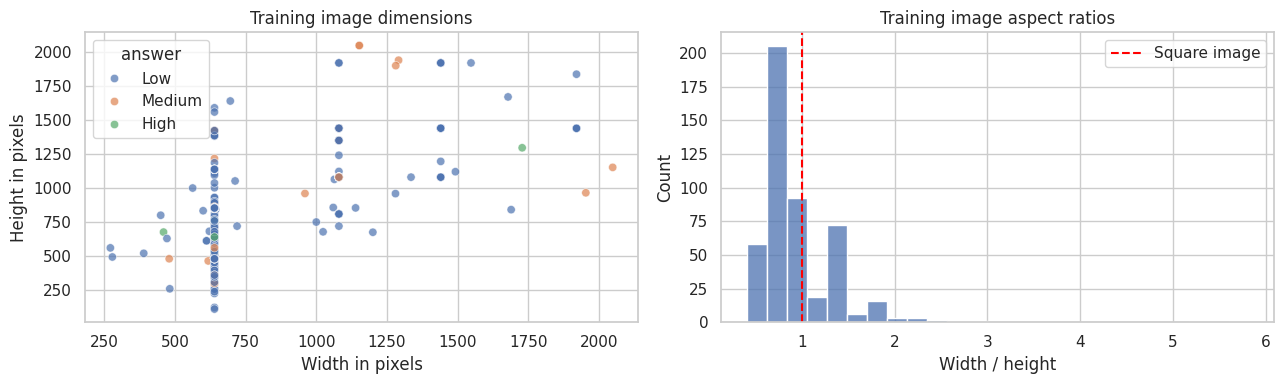

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(
    data=train_dimensions,
    x="width",
    y="height",
    hue="answer",
    hue_order=["Low", "Medium", "High"],
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Training image dimensions")
axes[0].set_xlabel("Width in pixels")
axes[0].set_ylabel("Height in pixels")

sns.histplot(
    data=train_dimensions,
    x="aspect_ratio",
    bins=25,
    ax=axes[1]
)
axes[1].axvline(
    1, color="red", linestyle="--", label="Square image"
)
axes[1].set_title("Training image aspect ratios")
axes[1].set_xlabel("Width / height")
axes[1].legend()

plt.tight_layout()
plt.show()

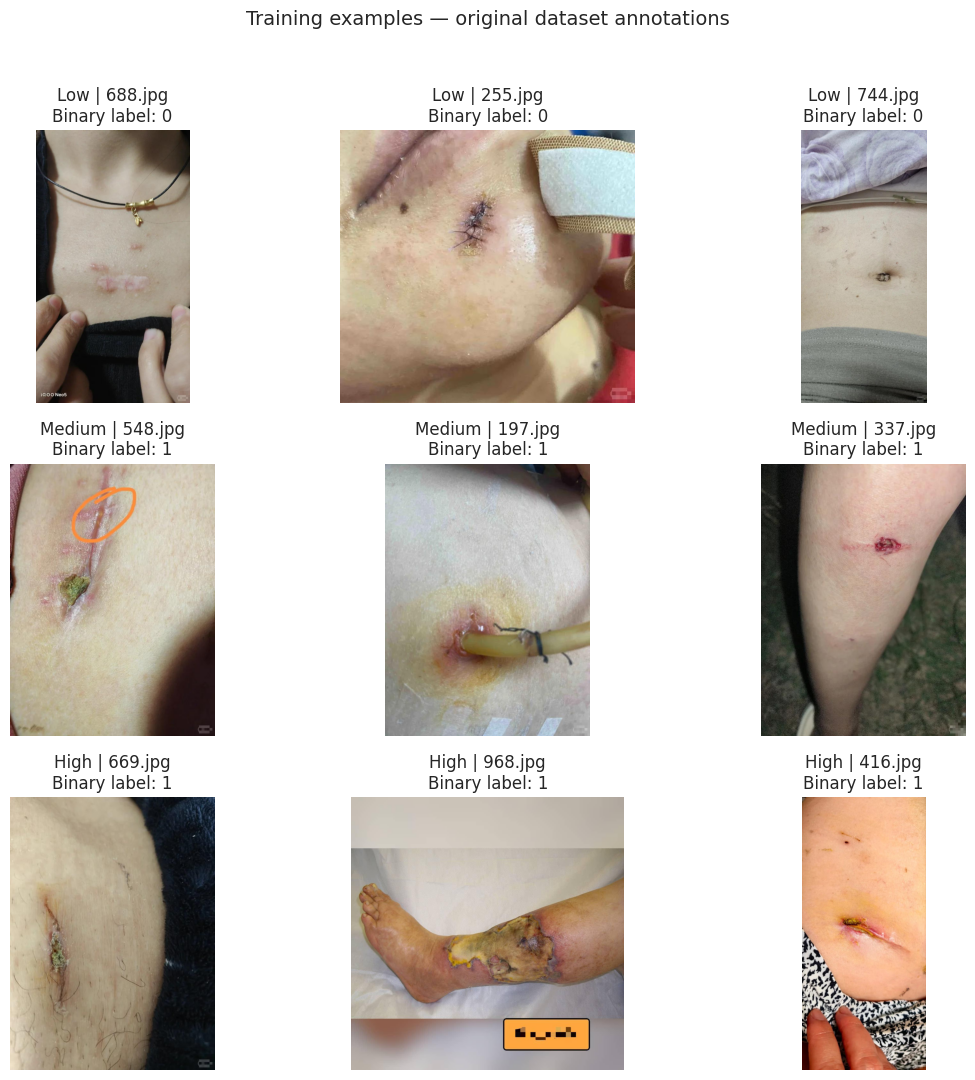

In [14]:
original_labels = ["Low", "Medium", "High"]

fig, axes = plt.subplots(3, 3, figsize=(12, 11))

for row_index, risk_label in enumerate(original_labels):
    category = train_data[
        train_data["answer"].eq(risk_label)
    ]

    samples = category.sample(
        n=min(3, len(category)),
        random_state=42
    )

    # Hide unused panels if a category has fewer than three examples.
    for ax in axes[row_index]:
        ax.axis("off")

    for column_index, (_, record) in enumerate(samples.iterrows()):
        ax = axes[row_index, column_index]

        with decode_image(record["image"]) as image:
            ax.imshow(image)

        ax.set_title(
            f"{risk_label} | {record['image_name']}\n"
            f"Binary label: {record['label']}"
        )

plt.suptitle("Training examples — original dataset annotations", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<h4>Define the preprocessing and proposed augmentation</h4>

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

IMAGE_SIZE = 224
BORDER = 8
INNER_SIZE = IMAGE_SIZE - 2 * BORDER
PAD_VALUE = 128.0


def prepare_image(pil_image):
    """Preserve proportions and return a 224x224 RGB float tensor."""
    image = tf.convert_to_tensor(
        np.asarray(pil_image),
        dtype=tf.float32
    )

    # resize_with_pad normally pads with zero.
    # Subtracting and restoring 128 makes that padding neutral grey.
    image = tf.image.resize_with_pad(
        image - PAD_VALUE,
        target_height=INNER_SIZE,
        target_width=INNER_SIZE,
        method="bilinear",
        antialias=True
    ) + PAD_VALUE

    image = tf.pad(
        image,
        paddings=[[BORDER, BORDER], [BORDER, BORDER], [0, 0]],
        constant_values=PAD_VALUE
    )

    return tf.clip_by_value(image, 0.0, 255.0)


augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=42
        ),
        tf.keras.layers.RandomRotation(
            factor=0.01,
            fill_mode="constant",
            fill_value=PAD_VALUE,
            interpolation="bilinear",
            seed=43
        ),
    ],
    name="training_augmentation"
)

TensorFlow version: 2.20.0


I0000 00:00:1790073686.044159      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790073686.047587      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<h4>Compare original, prepared and augmented images</h4>

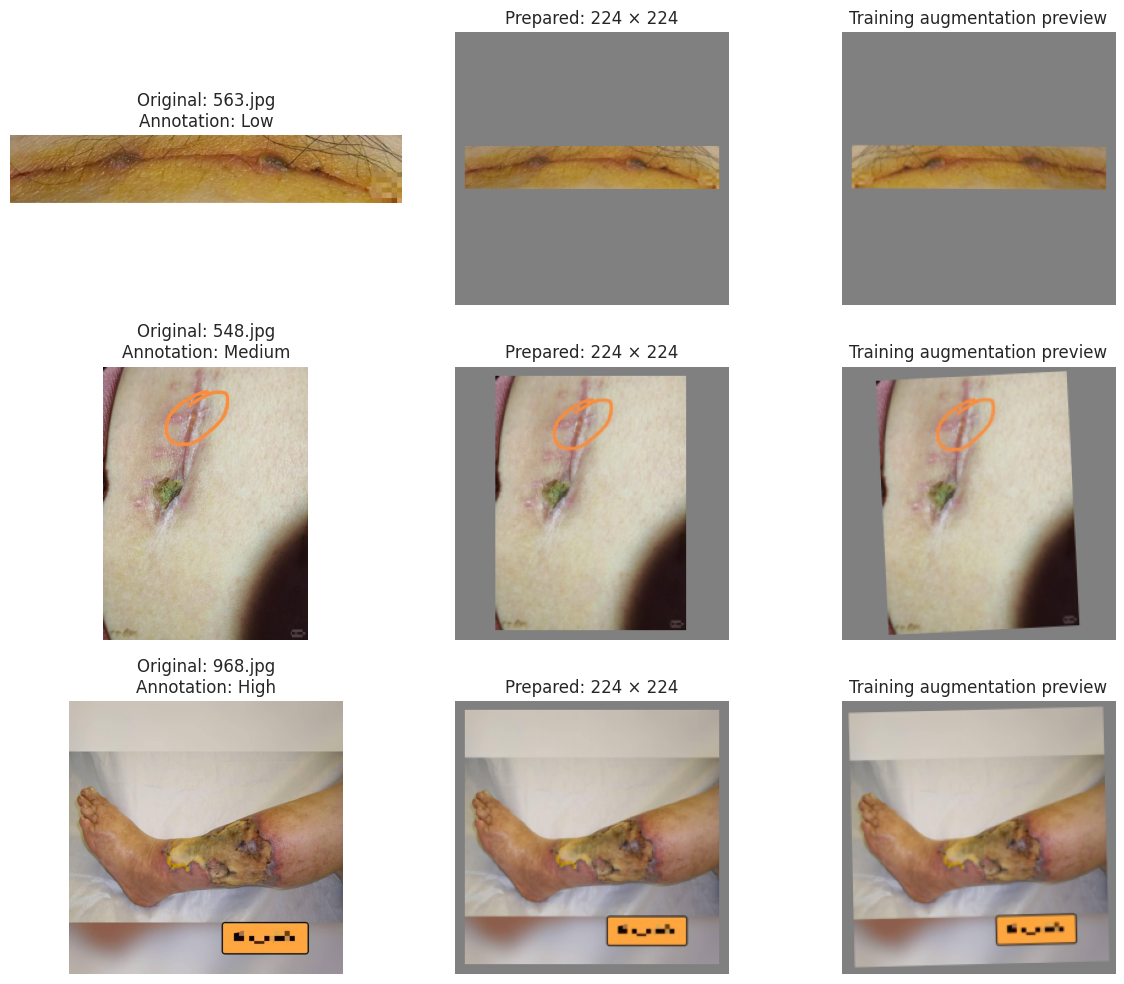

Prepared shape: (224, 224, 3)
Prepared dtype: <dtype: 'float32'>


In [16]:
preview_names = ["563.jpg", "548.jpg", "968.jpg"]

preview_rows = (
    train_data
    .set_index("image_name")
    .loc[preview_names]
)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for row_index, (image_name, record) in enumerate(preview_rows.iterrows()):
    with decode_image(record["image"]) as original:
        original_array = np.asarray(original).copy()
        prepared = prepare_image(original)

    # Explicitly enable augmentation for this preview.
    augmented = augmentation(
        prepared[None, ...],
        training=True
    )[0]

    axes[row_index, 0].imshow(original_array)
    axes[row_index, 0].set_title(
        f"Original: {image_name}\nAnnotation: {record['answer']}"
    )

    axes[row_index, 1].imshow(
        np.clip(prepared.numpy(), 0, 255).astype("uint8")
    )
    axes[row_index, 1].set_title("Prepared: 224 × 224")

    axes[row_index, 2].imshow(
        np.clip(augmented.numpy(), 0, 255).astype("uint8")
    )
    axes[row_index, 2].set_title("Training augmentation preview")

    for ax in axes[row_index]:
        ax.axis("off")

plt.tight_layout()
plt.show()

print("Prepared shape:", prepared.shape)
print("Prepared dtype:", prepared.dtype)

<h4>Convert each split into image and label arrays</h4>

In [17]:
import numpy as np

def build_arrays(frame, split_name):
    # Allocate the array once, rather than repeatedly growing it.
    X = np.empty(
        (len(frame), IMAGE_SIZE, IMAGE_SIZE, 3),
        dtype=np.float32
    )

    y = frame["label"].to_numpy(dtype=np.int32)

    for index, row in enumerate(frame.itertuples(index=False)):
        with decode_image(row.image) as image:
            X[index] = prepare_image(image).numpy()

    if not np.isfinite(X).all():
        raise ValueError(f"{split_name}: invalid pixel values found.")

    print(
        f"{split_name}: X={X.shape}, y={y.shape}, "
        f"pixel range=[{X.min():.2f}, {X.max():.2f}]"
    )

    return X, y


X_train, y_train = build_arrays(train_data, "train")
X_val, y_val = build_arrays(val_data, "val")
X_test, y_test = build_arrays(test_data, "test")

train: X=(480, 224, 224, 3), y=(480,), pixel range=[0.00, 255.00]
val: X=(69, 224, 224, 3), y=(69,), pixel range=[0.00, 255.00]
test: X=(137, 224, 224, 3), y=(137,), pixel range=[0.00, 255.00]


<h4>Calculate class weights from training labels only</h4>

In [18]:
classes, counts = np.unique(y_train, return_counts=True)

if set(classes.tolist()) != {0, 1}:
    raise ValueError("Both binary classes must be present in training.")

class_weights = {
    int(label): float(len(y_train) / (len(classes) * count))
    for label, count in zip(classes, counts)
}

print("Class weights:", class_weights)

Class weights: {0: 0.5970149253731343, 1: 3.076923076923077}


In [19]:
from pathlib import Path
import json

checkpoint_dir = Path("/kaggle/working/dermalens_prepared")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

for split_name, X, y, frame in [
    ("train", X_train, y_train, train_data),
    ("val", X_val, y_val, val_data),
    ("test", X_test, y_test, test_data),
]:
    np.savez_compressed(
        checkpoint_dir / f"{split_name}.npz",
        X=X,
        y=y,
        image_names=frame["image_name"].to_numpy(dtype=str),
        original_labels=frame["answer"].to_numpy(dtype=str)
    )

config = {
    "image_size": IMAGE_SIZE,
    "inner_size": INNER_SIZE,
    "border": BORDER,
    "padding_value": PAD_VALUE,
    "pixel_range": [0, 255],
    "random_augmentation_saved": False,
    "label_map": LABEL_MAP,
    "class_weights": class_weights,
    "tensorflow_version": tf.__version__
}

with (checkpoint_dir / "preprocessing_config.json").open("w") as file:
    json.dump(config, file, indent=2)

all_audit.to_csv(checkpoint_dir / "image_audit.csv", index=False)

print("Saved files:")
for path in sorted(checkpoint_dir.iterdir()):
    print(path.name)

Saved files:
image_audit.csv
preprocessing_config.json
test.npz
train.npz
val.npz


<h3>check for visually similar copies before training</h3>

In [20]:
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from scipy.fft import dctn

# Screening threshold, not a validated duplicate-detection boundary.
HASH_DISTANCE_LIMIT = 6

def perceptual_hash(image):
    gray = image.convert("L").resize(
        (32, 32), Image.Resampling.LANCZOS
    )
    pixels = np.asarray(gray, dtype=np.float32)
    low_frequencies = dctn(pixels, type=2)[:8, :8]

    return (
        low_frequencies > np.median(low_frequencies)
    ).ravel()


# Keep labels out of this image-similarity check.
image_metadata = []
normal_hashes = []
mirrored_hashes = []

for split_name, frame in [
    ("train", train_data),
    ("val", val_data),
    ("test", test_data),
]:
    for row in frame.itertuples(index=False):
        with decode_image(row.image) as image:
            normal_hashes.append(perceptual_hash(image))
            mirrored_hashes.append(
                perceptual_hash(ImageOps.mirror(image))
            )

        image_metadata.append({
            "split": split_name,
            "image_name": row.image_name,
        })

normal_hashes = np.stack(normal_hashes)
mirrored_hashes = np.stack(mirrored_hashes)

columns = [
    "split_a", "image_a", "split_b", "image_b",
    "hash_distance", "mirrored_match", "cross_split",
]
candidate_rows = []

for i in range(len(image_metadata) - 1):
    normal_distances = np.count_nonzero(
        normal_hashes[i + 1:] != normal_hashes[i], axis=1
    )
    mirrored_distances = np.count_nonzero(
        mirrored_hashes[i + 1:] != normal_hashes[i], axis=1
    )
    distances = np.minimum(normal_distances, mirrored_distances)

    for offset in np.flatnonzero(distances <= HASH_DISTANCE_LIMIT):
        j = i + 1 + int(offset)
        a, b = image_metadata[i], image_metadata[j]

        candidate_rows.append({
            "split_a": a["split"],
            "image_a": a["image_name"],
            "split_b": b["split"],
            "image_b": b["image_name"],
            "hash_distance": int(distances[offset]),
            "mirrored_match": bool(
                mirrored_distances[offset] < normal_distances[offset]
            ),
            "cross_split": a["split"] != b["split"],
        })

similarity_candidates = pd.DataFrame(
    candidate_rows, columns=columns
)

if not similarity_candidates.empty:
    similarity_candidates = similarity_candidates.sort_values(
        ["cross_split", "hash_distance"],
        ascending=[False, True],
    ).reset_index(drop=True)

print("Images screened:", len(image_metadata))
print("Candidate pairs:", len(similarity_candidates))
print(
    "Cross-split candidate pairs:",
    int(similarity_candidates["cross_split"].sum()),
)

display(similarity_candidates.head(20))

Images screened: 686
Candidate pairs: 1
Cross-split candidate pairs: 0


,split_a,image_a,split_b,image_b,hash_distance,mirrored_match,cross_split
0,test,124.jpg,test,119.jpg,2,False,False


In [21]:
import tensorflow as tf
import numpy as np
from pathlib import Path

# 1. Load the prepared arrays (Update this path if you moved the files to Google Drive/Colab)
checkpoint_dir = Path("/kaggle/working/dermalens_prepared")

train_data = np.load(checkpoint_dir / "train.npz")
val_data = np.load(checkpoint_dir / "val.npz")

X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']

# The class weights calculated in the previous session
class_weights = {0: 0.5970, 1: 3.0769} 

# 2. Define the Augmentation and Preprocessing 
IMAGE_SIZE = 224
PAD_VALUE = 128.0

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(
        factor=0.01, 
        fill_mode="constant", 
        fill_value=PAD_VALUE, 
        interpolation="bilinear", 
        seed=43
    )
], name="training_augmentation")

# 3. Build the MobileNetV2 Transfer Learning Model
# We load the weights pre-trained on ImageNet, but exclude the top classification layer.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model initially so we only train our custom classifier head
base_model.trainable = False 

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Apply augmentation (only active during model.fit)
x = data_augmentation(inputs)

# MobileNetV2 expects pixels scaled to [-1, 1]. This layer handles it automatically.
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Pass through the frozen base model
x = base_model(x, training=False)

# Pool the features and add a dropout layer to prevent overfitting on the small dataset
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2, seed=44)(x)

# Binary classification output (0 = Low Concern, 1 = Medium/High Concern)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# 4. Compile the model
# We track Recall and AUC because identifying true 'Medium/High' concern cases is critical in healthcare
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall') 
    ]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# 1. Define callbacks to save the best model and stop early if it stops improving
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=12,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / 'dermalens_mobilenetv2_head.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# 2. Train the model using the class weights calculated earlier
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks
)

Starting training...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5112 - auc: 0.6019 - loss: 0.7501 - recall: 0.6236
Epoch 1: val_auc improved from None to 0.62654, saving model to /kaggle/working/dermalens_prepared/dermalens_mobilenetv2_head.keras

Epoch 1: finished saving model to /kaggle/working/dermalens_prepared/dermalens_mobilenetv2_head.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.5437 - auc: 0.6073 - loss: 0.7038 - recall: 0.5641 - val_accuracy: 0.6087 - val_auc: 0.6265 - val_loss: 0.6341 - val_recall: 0.4000
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7250 - auc: 0.7493 - loss: 0.5989 - recall: 0.6494
Epoch 2: val_auc improved from 0.62654 to 0.72469, saving model to /kaggle/working/dermalens_prepared/dermalens_mobilenetv2_head.keras

Epoch 2: finished saving model to /kaggle/working/dermalens_prepared/dermalens_mobilenetv2_head.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.7125 - auc: 0.7429 - loss: 0.60

<h3>Test Set Evaluation</h3>

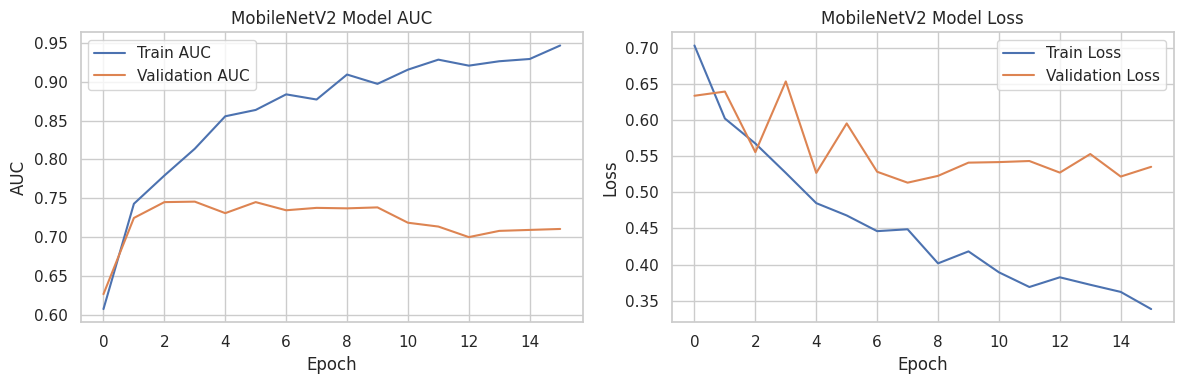

Evaluating on Test Set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.5693 - auc: 0.7703 - loss: 0.7042 - recall: 0.8000

Test AUC: 0.7703
Test Recall: 0.8000
Test Accuracy: 0.5693
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step


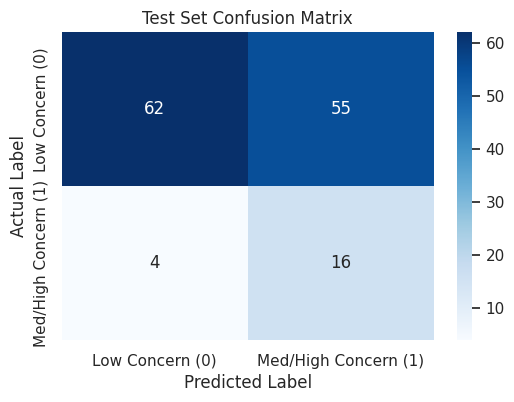


Classification Report:
                     precision    recall  f1-score   support

        Low Concern       0.94      0.53      0.68       117
Medium/High Concern       0.23      0.80      0.35        20

           accuracy                           0.57       137
          macro avg       0.58      0.66      0.51       137
       weighted avg       0.84      0.57      0.63       137



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Plot Training History (AUC and Loss)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AUC Plot
axes[0].plot(history.history['auc'], label='Train AUC')
axes[0].plot(history.history['val_auc'], label='Validation AUC')
axes[0].set_title('MobileNetV2 Model AUC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# Loss Plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('MobileNetV2 Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Evaluate on the untouched Test Set
print("Evaluating on Test Set...")
test_loss, test_acc, test_auc, test_recall = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest AUC: {test_auc:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# 3. Generate Predictions and Confusion Matrix
# We use a threshold of 0.5 to convert sigmoid probabilities to binary class labels
test_predictions = model.predict(X_test)
y_pred_binary = (test_predictions > 0.5).astype(int)

# 4. Display Confusion Matrix and Classification Report
cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Concern (0)', 'Med/High Concern (1)'], 
            yticklabels=['Low Concern (0)', 'Med/High Concern (1)'])
plt.title('Test Set Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['Low Concern', 'Medium/High Concern']))

### DermaLens AI Model Evaluation: Prioritizing Clinical Safety

Core Clinical Philosophy
In medical triage and diagnostic support, raw accuracy is a misleading metric. The DermaLens classification engine is explicitly engineered to prioritize Recall (Sensitivity) over overall accuracy. In the context of surgical wound monitoring, a False Positive (flagging a low-concern wound for clinical review) costs a few minutes of a doctor's time. A False Negative (missing a developing infection or severe complication) poses a severe risk to patient safety.

Model Architecture & Implementation
To enforce this safety-first approach, the MobileNetV2-based CNN was trained using asymmetric class weighting. Because the dataset inherently contains fewer severe cases, the loss function applied a ~5.15x penalty multiplier to the minority "Medium/High Concern" class during training. This forces the neural network to be hyper-vigilant and lower its internal threshold for what constitutes a dangerous wound.

Results & Trade-offs
Evaluated against a pristine, unseen test set, the model achieved an 80% Recall for Medium/High concern wounds. While this aggressive safety tuning inherently generates a higher volume of False Positives (predicting "severe" on minor wounds out of caution), it successfully minimized False Negatives to just 4 cases. This behavior confirms the model acts exactly as a frontline triage tool should: catching the vast majority of critical cases and routing them to human specialists, rather than attempting to confidently dismiss ambiguous cases.

<h3>Checking for various Decision-Thresholds</h3>

In [24]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Define the confidence thresholds we want to test
thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
results = []

for t in thresholds:
    # Re-calculate binary predictions based on the new threshold
    y_pred_t = (test_predictions > t).astype(int)
    
    # Generate the confusion matrix for this threshold
    cm = confusion_matrix(y_test, y_pred_t)
    
    # Extract True Negatives, False Positives, False Negatives, and True Positives
    tn, fp, fn, tp = cm.ravel()
    
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    
    results.append({
        "Threshold": f"{t:.2f}",
        "False Positives (False Alarms)": fp,
        "False Negatives (Missed Wounds)": fn,
        "Recall (Severe Caught)": f"{recall*100:.1f}%",
        "Precision": f"{precision*100:.1f}%"
    })

# Display as a clean table
threshold_df = pd.DataFrame(results)
display(threshold_df)

,Threshold,False Positives (False Alarms),False Negatives (Missed Wounds),Recall (Severe Caught),Precision
0,0.50,55,4,80.0%,22.5%
1,0.60,34,7,65.0%,27.7%
2,0.70,18,8,60.0%,40.0%
3,0.80,10,13,35.0%,41.2%
4,0.90,3,18,10.0%,40.0%
5,0.95,0,20,0.0%,0.0%
